In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.3 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!rm -rf /content/drive/MyDrive/weapon_detection_final

In [ ]:
from ultralytics import YOLO
import os
import glob
import cv2
import matplotlib.pyplot as plt

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
import zipfile

zip_path = '/content/drive/MyDrive/weapon_detection_final.zip'
extract_path = '/content/drive/MyDrive/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [ ]:
import os

dataset_path = "/content/drive/MyDrive/weapon_detection_final"

for root, dirs, files in os.walk(dataset_path):
    print(root)

/content/drive/MyDrive/weapon_detection_final
/content/drive/MyDrive/weapon_detection_final/test
/content/drive/MyDrive/weapon_detection_final/test/images
/content/drive/MyDrive/weapon_detection_final/test/labels
/content/drive/MyDrive/weapon_detection_final/train
/content/drive/MyDrive/weapon_detection_final/train/images
/content/drive/MyDrive/weapon_detection_final/train/labels
/content/drive/MyDrive/weapon_detection_final/valid
/content/drive/MyDrive/weapon_detection_final/valid/images
/content/drive/MyDrive/weapon_detection_final/valid/labels


In [ ]:
import glob
import os

dataset_path = "/content/drive/MyDrive/weapon_detection_final/"

def validate_split(split):
    img_path = f"{dataset_path}/{split}/images"
    lbl_path = f"{dataset_path}/{split}/labels"

    images = glob.glob(img_path + "/*.jpg")
    labels = glob.glob(lbl_path + "/*.txt")

    print(f"\n--- {split.upper()} ---")
    print("Images:", len(images))
    print("Labels:", len(labels))

    missing_labels = []
    for img in images:
        label = img.replace("images", "labels").replace(".jpg", ".txt")
        if not os.path.exists(label):
            missing_labels.append(img)

    print("Missing Labels:", len(missing_labels))

validate_split("train")
validate_split("valid")
validate_split("test")


--- TRAIN ---
Images: 1125
Labels: 1125
Missing Labels: 0

--- VALID ---
Images: 155
Labels: 155
Missing Labels: 0

--- TEST ---
Images: 101
Labels: 101
Missing Labels: 0


In [ ]:
import glob
import os

dataset_path = "/content/drive/MyDrive/weapon_detection_final/"

def check_empty_labels(split):
    lbl_path = f"{dataset_path}/{split}/labels"
    label_files = glob.glob(lbl_path + "/*.txt")

    empty = 0
    for file in label_files:
        if os.path.getsize(file) == 0:
            empty += 1

    print(f"{split} empty labels:", empty)

check_empty_labels("train")
check_empty_labels("valid")
check_empty_labels("test")

train empty labels: 36
valid empty labels: 26
test empty labels: 26


In [ ]:
from collections import Counter
import glob

def class_distribution(split):
    lbl_path = f"{dataset_path}/{split}/labels"
    label_files = glob.glob(lbl_path + "/*.txt")

    classes = []

    for file in label_files:
        with open(file, 'r') as f:
            for line in f.readlines():
                cls = int(line.split()[0])
                classes.append(cls)

    print(f"\n{split} class distribution:")
    print(Counter(classes))

class_distribution("train")


train class distribution:
Counter({3: 339, 4: 285, 8: 249, 0: 222, 5: 195, 7: 171, 2: 162, 1: 132, 6: 129, 9: 55, 10: 21})


In [ ]:
with open(dataset_path + "/data.yaml") as f:
    print(f.read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 11
names: ['Automatic Rifle', 'Bazooka', 'Grenade Launcher', 'Handgun', 'Knife', 'SMG', 'Shotgun', 'Sniper', 'Sword','Chef Knife','Butcher knife']

roboflow:
  workspace: harshavardhan-adefc
  project: weapon-detection-ndkao
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/harshavardhan-adefc/weapon-detection-ndkao/dataset/1


In [ ]:
data_yaml_path = dataset_path + "/data.yaml"

content = """
train: /content/drive/MyDrive/weapon_detection_final/train/images
val: /content/drive/MyDrive/weapon_detection_final/valid/images
test: /content/drive/MyDrive/weapon_detection_final/test/images

nc: 11
names: ['Automatic_Rifle', 'Bazooka', 'Grenade_Launcher', 'Handgun', 'Knife', 'SMG', 'Shotgun', 'Sniper', 'Sword', 'Chef_Knife', 'Butcher_Knife']

roboflow:
  workspace: harshavardhan-adefc
  project: weapon-detection-ndkao
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/harshavardhan-adefc/weapon-detection-ndkao/dataset/1
"""

with open(data_yaml_path, "w") as f:
    f.write(content)

print("data.yaml updated successfully")

data.yaml updated successfully


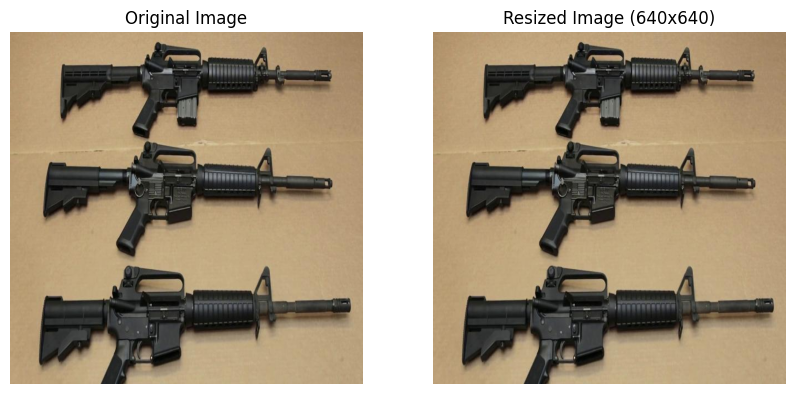

In [ ]:
import cv2
import os
import matplotlib.pyplot as plt

img_dir = "/content/drive/MyDrive/weapon_detection_final/train/images"

# Take one sample image
img_file = os.listdir(img_dir)[0]
path = os.path.join(img_dir, img_file)

img = cv2.imread(path)
resized = cv2.resize(img, (640, 640))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Resized Image (640x640)")
plt.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.show()

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/content/drive/MyDrive/weapon_detection_final/train/images/" + os.listdir("/content/drive/MyDrive/weapon_detection_final/train/images")[0])

normalized = img / 255.0

print("Before normalization:", img[0][0])
print("After normalization:", normalized[0][0])

Before normalization: [ 99 138 170]
After normalization: [    0.38824     0.54118     0.66667]


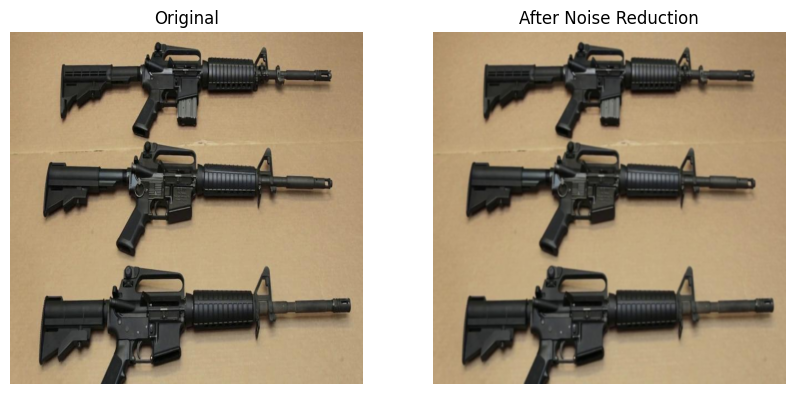

In [ ]:
import cv2
import matplotlib.pyplot as plt

img_path = "/content/drive/MyDrive/weapon_detection_final/train/images/" + os.listdir("/content/drive/MyDrive/weapon_detection_final/train/images")[0]

img = cv2.imread(img_path)

# Applying Gaussian Blur (noise reduction)
denoised = cv2.GaussianBlur(img, (5,5), 0)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1,2,2)
plt.title("After Noise Reduction")
plt.imshow(cv2.cvtColor(denoised, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.show()

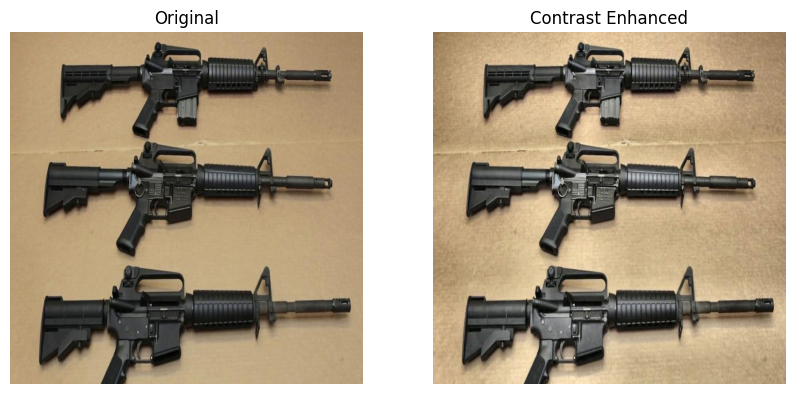

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os

img_path = "/content/drive/MyDrive/weapon_detection_final/train/images/" + os.listdir("/content/drive/MyDrive/weapon_detection_final/train/images")[0]

img = cv2.imread(img_path)

# Convert to LAB color space
lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(lab)

# Apply CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
cl = clahe.apply(l)

# Merge channels
limg = cv2.merge((cl, a, b))
enhanced = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)

# Display
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Contrast Enhanced")
plt.imshow(cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.show()

In [ ]:
import cv2
import os
import glob
import random
from collections import Counter

img_dir = dataset_path + "/train/images"
lbl_dir = dataset_path + "/train/labels"

target_classes = [9, 10]
TARGET = 150

label_files = glob.glob(lbl_dir + "/*.txt")

# Get initial distribution
classes = []
for file in label_files:
    with open(file, 'r') as f:
        for line in f.readlines():
            classes.append(int(line.split()[0]))

dist = Counter(classes)
print("Before:", dist)

saved = 0

# LOOP until target reached
while any(dist[cls] < TARGET for cls in target_classes):

    for label_file in label_files:
        with open(label_file, 'r') as f:
            lines = f.readlines()

        class_ids = [int(line.split()[0]) for line in lines]

        if any(cls in target_classes for cls in class_ids):

            for cls in class_ids:
                if cls in target_classes and dist[cls] < TARGET:

                    base = os.path.splitext(os.path.basename(label_file))[0]

                    img_file = None
                    for ext in [".jpg", ".png", ".jpeg"]:
                        path = os.path.join(img_dir, base + ext)
                        if os.path.exists(path):
                            img_file = path
                            break

                    if img_file is None:
                        continue

                    img = cv2.imread(img_file)
                    aug_img = img.copy()

                    if random.random() < 0.5:
                        aug_img = cv2.flip(aug_img, 1)

                    value = random.randint(-30, 30)
                    aug_img = cv2.convertScaleAbs(aug_img, alpha=1, beta=value)

                    new_img = os.path.join(img_dir, f"aug_{saved}.jpg")
                    new_lbl = os.path.join(lbl_dir, f"aug_{saved}.txt")

                    cv2.imwrite(new_img, aug_img)

                    with open(new_lbl, 'w') as f:
                        f.writelines(lines)

                    saved += 1
                    dist[cls] += 1

                    if all(dist[c] >= TARGET for c in target_classes):
                        break

        if all(dist[c] >= TARGET for c in target_classes):
            break

print("After:", dist)
print("Augmentation done")

Before: Counter({3: 339, 4: 285, 8: 249, 0: 222, 5: 195, 7: 171, 2: 162, 1: 132, 6: 129, 9: 55, 10: 21})
After: Counter({3: 339, 4: 285, 8: 249, 0: 222, 5: 195, 7: 171, 2: 162, 10: 150, 9: 150, 1: 132, 6: 129})
Augmentation done


In [ ]:
class_images = {
    0: "/content/drive/MyDrive/weapon_detection_final/train/images/Automatic-Rifle_66_jpeg.rf.669c7a4666b186b0168d40108d478a5c.jpg",
    1: "/content/drive/MyDrive/weapon_detection_final/train/images/Bazooka_32_jpeg.rf.25cc8bc1d1f022f003c3deeac1e6a464.jpg",
    2: "/content/drive/MyDrive/weapon_detection_final/train/images/Grenade-Launcher_76_jpeg.rf.7a4814860b143acf0035b18dc168ce78.jpg",
    3: "/content/drive/MyDrive/weapon_detection_final/train/images/Handgun_58_jpeg.rf.f684788a296b3976b9fcc73f3eac06a5.jpg",
    4: "/content/drive/MyDrive/weapon_detection_final/train/images/Knife_27_png.rf.6cb73176714a0b2e7d6d484202b43ddd.jpg",
    5: "/content/drive/MyDrive/weapon_detection_final/train/images/SMG_50_jpeg.rf.851e7ffa8bcdb45416cbefd889d0573b.jpg",
    6: "/content/drive/MyDrive/weapon_detection_final/train/images/Shotgun_25_jpeg.rf.5e27b8af257f8b55c923a7ec56171b29.jpg",
    7: "/content/drive/MyDrive/weapon_detection_final/train/images/Sniper_22_jpeg.rf.e89f02b33bc1c3934b9b6b6f1f52a619.jpg",
    8: "/content/drive/MyDrive/weapon_detection_final/train/images/Sword_55_jpeg.rf.ea4a6153b47c7fd042735bdffffaac63.jpg",
    9: "/content/drive/MyDrive/weapon_detection_final/train/images/chef_knife_8.jpg",
    10: "/content/drive/MyDrive/weapon_detection_final/train/images/butcher_knife_8.jpg"
}

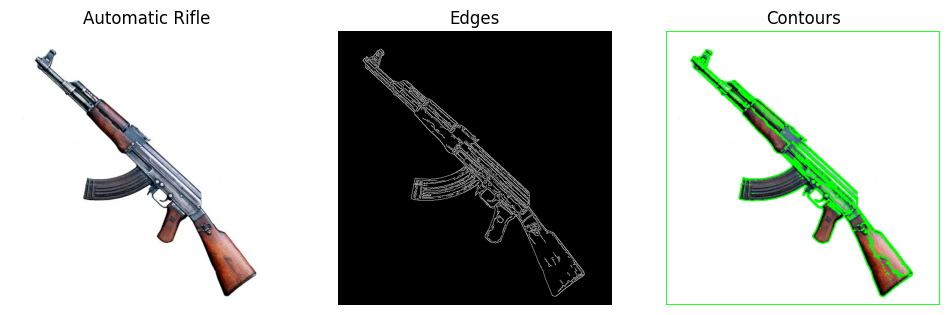

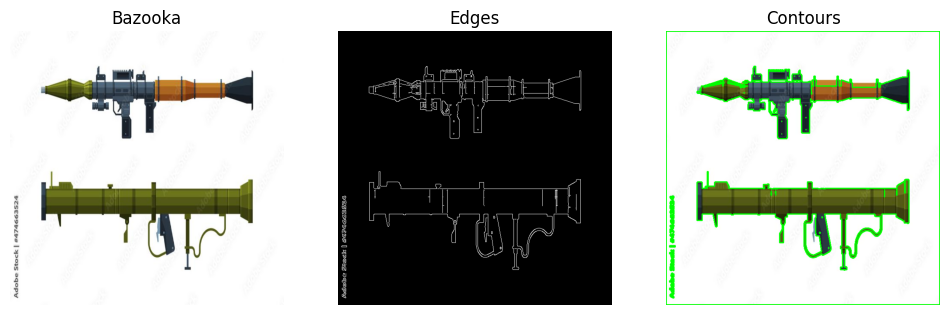

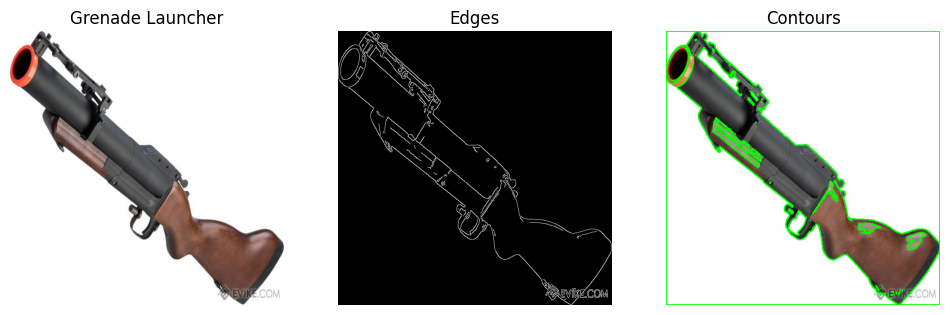

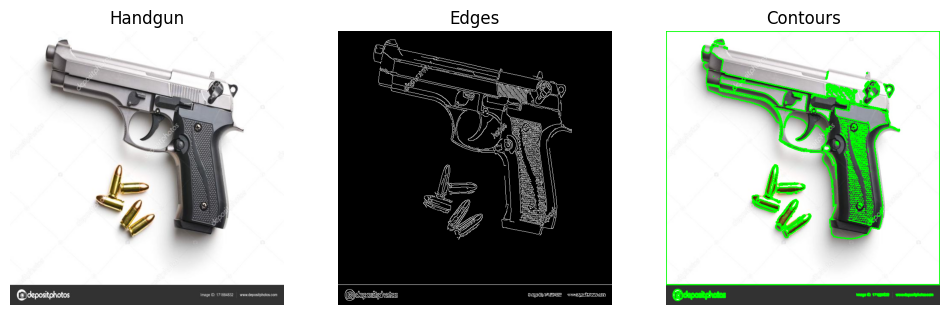

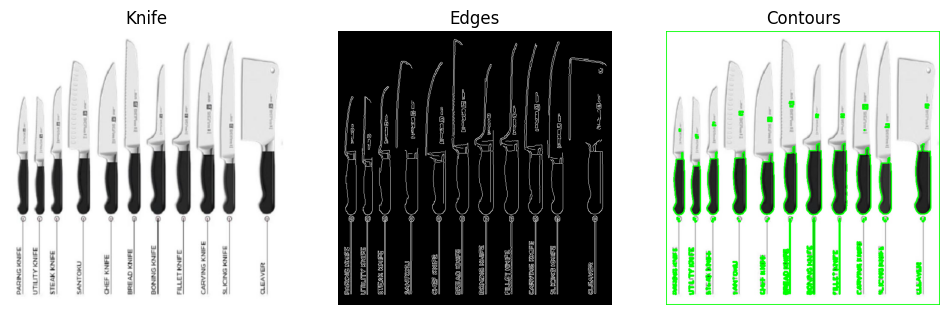

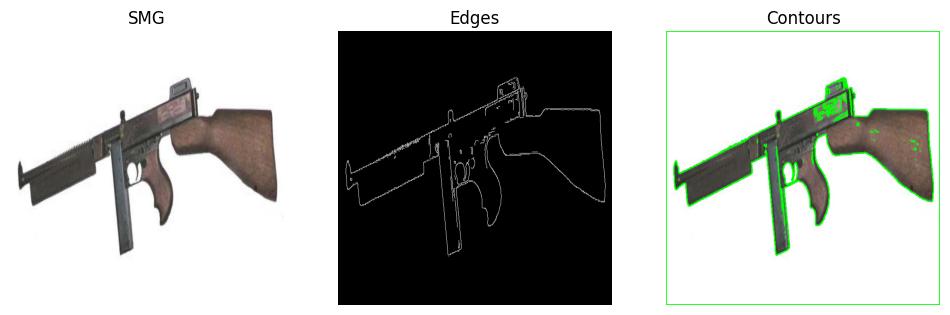

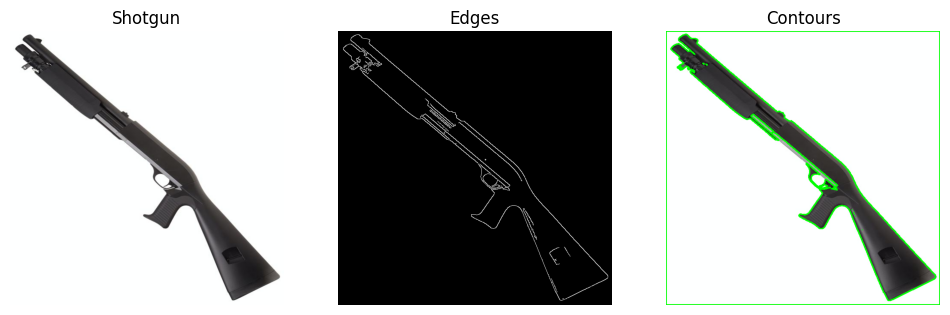

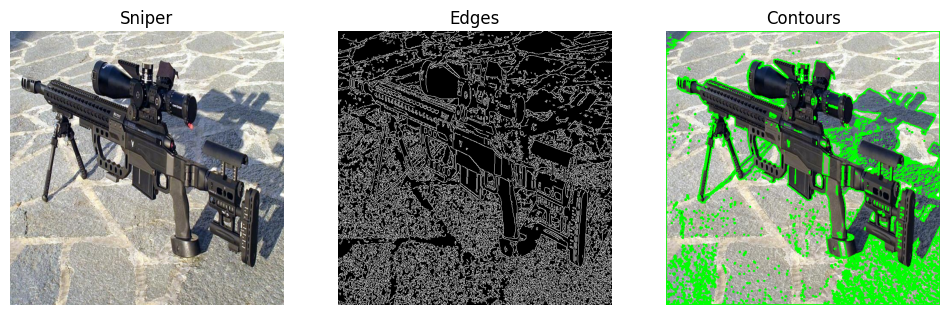

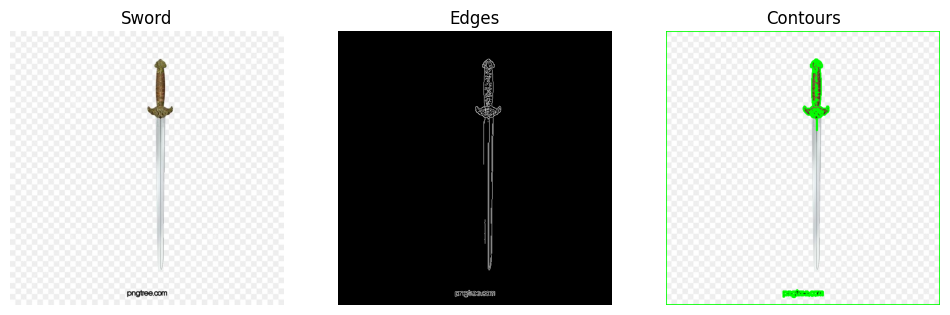

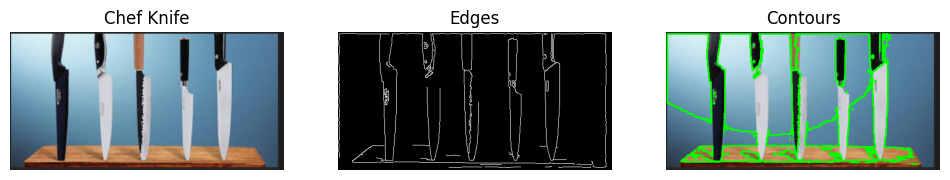

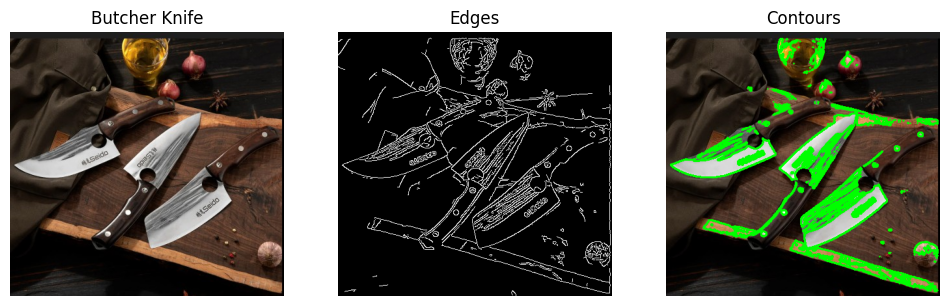

In [ ]:
import cv2
import matplotlib.pyplot as plt

names = ['Automatic Rifle', 'Bazooka', 'Grenade Launcher', 'Handgun', 'Knife',
         'SMG', 'Shotgun', 'Sniper', 'Sword', 'Chef Knife', 'Butcher Knife']

for cls, img_path in class_images.items():

    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Edge detection
    edges = cv2.Canny(gray, 100, 200)

    # Contours
    _, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    contour_img = img.copy()
    cv2.drawContours(contour_img, contours, -1, (0,255,0), 2)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.title(names[cls])
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.title("Edges")
    plt.imshow(edges, cmap='gray')
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.title("Contours")
    plt.imshow(cv2.cvtColor(contour_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.show()

In [ ]:
from ultralytics import YOLO
model = YOLO("yolo12s.pt")

In [ ]:
dataset_path = "/content/drive/MyDrive/weapon_detection_final"

In [ ]:
results = model.train(
    data=dataset_path + "/data.yaml",
    epochs=120,
    imgsz=640,
    batch=8,
    device=0,

    optimizer="SGD",
    lr0=0.01,
    lrf=0.01,
    momentum=0.937,
    weight_decay=0.0005,

    augment=True,
    degrees=10,
    translate=0.1,
    scale=0.5,
    shear=2.0,
    fliplr=0.5,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,

    patience=30,
    cache="disk",
    workers=4,
    amp=True
)
print("Training completed")

Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/weapon_detection_final/data.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=120, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mask=True, patien

In [ ]:
metrics = model.val()
print("Model Evaluation Metrics\n")

print(f"Accuracy: {metrics.box.map50}")
print(f"mAP@0.5:0.95: {metrics.box.map}")
print(f"Precision: {metrics.box.mp}")
print(f"Recall: {metrics.box.mr}")

Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv12s summary (fused): 159 layers, 9,235,137 parameters, 0 gradients, 21.2 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.4 ms, read: 17.4±15.4 MB/s, size: 39.8 KB)
val: Scanning /content/drive/MyDrive/weapon_detection_final/valid/labels.cache... 155 images, 26 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 155/155 25.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 2.3it/s 4.4s
                   all        155        277      0.683      0.698      0.755      0.566
       Automatic_Rifle          8         35      0.826      0.657      0.842      0.653
               Bazooka         12         13      0.597      0.572      0.598      0.401
      Grenade_Launcher          8          9      0.358      0.556      0.635      0.491
               Handgun          8         29      0.664      0.862      0.864      0.788
                 

In [ ]:
!ls /content/runs/detect

train  val


In [ ]:
from ultralytics import YOLO

best_model = YOLO("/content/runs/detect/train/weights/best.pt")

In [ ]:
image_path = "/content/drive/MyDrive/weapon_detection_final/test/images/Automatic-Rifle_5_jpeg.rf.706d30c0d73d5894c8866fa911585e25.jpg"

In [ ]:
results = best_model([image_path])
result = results[0]


0: 640x640 1 Automatic_Rifle, 27.6ms
Speed: 2.8ms preprocess, 27.6ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)


In [1]:
weapon_rules = {
    "knife": {"lower": 0.40, "upper": 0.70, "threat": "LOW"},
    "chef knife": {"lower": 0.45, "upper": 0.75, "threat": "MEDIUM"},
    "butcher knife": {"lower": 0.50, "upper": 0.90, "threat": "VERY HIGH"},
    "revolver": {"lower": 0.55, "upper": 0.75, "threat": "HIGH"},
    "pistol": {"lower": 0.60, "upper": 0.85, "threat": "HIGH"},
    "sniper": {"lower": 0.70, "upper": 0.90, "threat": "HIGH"},
    "automatic rifle": {"lower": 0.60, "upper": 0.90, "threat": "VERY HIGH"},
    "smg": {"lower": 0.55, "upper": 0.85, "threat": "HIGH"},
    "shotgun": {"lower": 0.55, "upper": 0.85, "threat": "HIGH"},
    "handgun": {"lower": 0.55, "upper": 0.80, "threat": "HIGH"}
}

In [ ]:
print("\nDetection Results with Threat Analysis\n")

total_risk = 0

for box in result.boxes:

    cls_id = int(box.cls[0])
    conf = float(box.conf[0])

    class_name = best_model.names[cls_id].lower()

    rule = weapon_rules.get(class_name)

    if rule:

        lower = rule["lower"]
        upper = rule["upper"]

        if conf < lower:
            threat = "Rejected Detection (Low Confidence)"

        elif lower <= conf <= upper:
            threat = rule["threat"]

        else:
            threat = "CRITICAL"

    else:
        # Default confidence-based threat classification

        if conf < 0.40:
            threat = "LOW"

        elif conf < 0.70:
            threat = "MEDIUM"

        else:
            threat = "HIGH"

    print("Weapon:", class_name)
    print("Confidence:", round(conf,3))
    print("Threat Level:", threat)


Detection Results with Threat Analysis

Weapon: automatic_rifle
Confidence: 0.899
Threat Level: HIGH


(np.float64(-0.5), np.float64(639.5), np.float64(639.5), np.float64(-0.5))

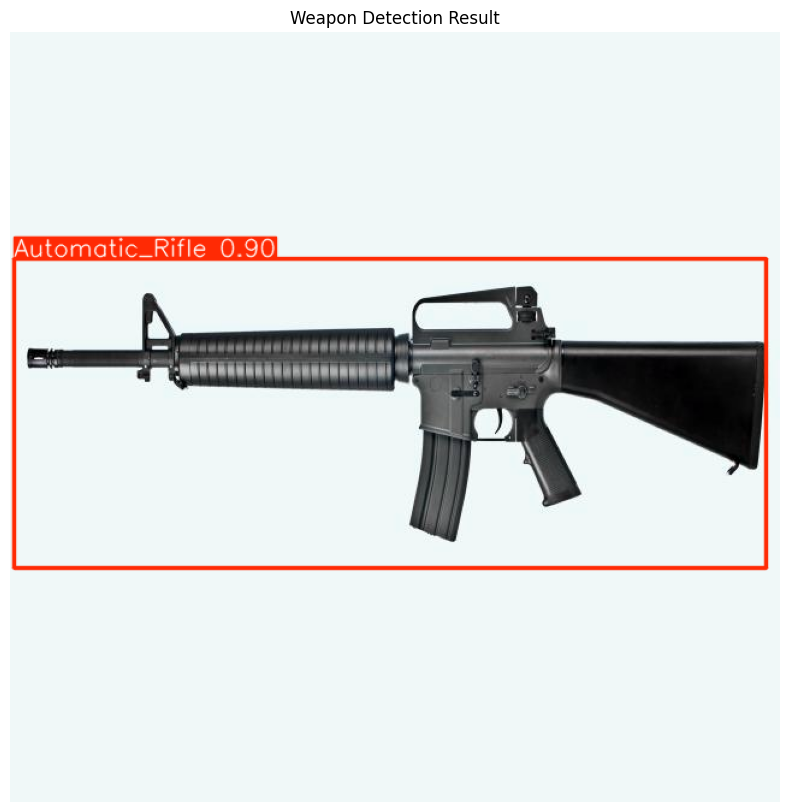

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))

# Plot detection result with bounding boxes
plt.imshow(result.plot())

plt.title("Weapon Detection Result")
plt.axis("off")

(np.float64(-0.5), np.float64(2999.5), np.float64(2249.5), np.float64(-0.5))

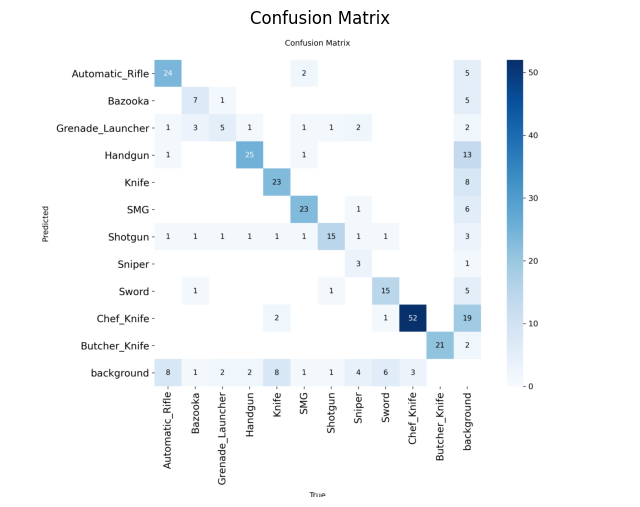

In [ ]:
import matplotlib.pyplot as plt
import cv2

cm_path = "/content/runs/detect/val/confusion_matrix.png"

img = cv2.imread(cm_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.title("Confusion Matrix")
plt.axis("off")

In [ ]:
import pandas as pd

results = pd.read_csv("/content/runs/detect/train/results.csv")

results.head()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,83.9692,1.81058,3.56992,2.15542,0.23971,0.37322,0.20611,0.10211,1.88238,2.98831,2.23042,0.003314,0.003314,0.070178
1,2,132.1590,1.68747,2.62454,1.96795,0.39607,0.35379,0.34251,0.19393,1.86888,2.39157,2.21936,0.006592,0.006592,0.040123
2,3,179.6670,1.74187,2.60214,1.99223,0.40697,0.26016,0.17443,0.08118,2.12031,3.31448,2.47523,0.009816,0.009816,0.010013
3,4,227.4030,1.80136,2.67276,2.05215,0.62802,0.14116,0.17656,0.08390,2.23148,3.48396,2.64198,0.009753,0.009753,0.009753
4,5,276.1220,1.79338,2.70471,2.06006,0.34345,0.26325,0.18627,0.08588,2.18566,3.46639,2.61543,0.009670,0.009670,0.009670


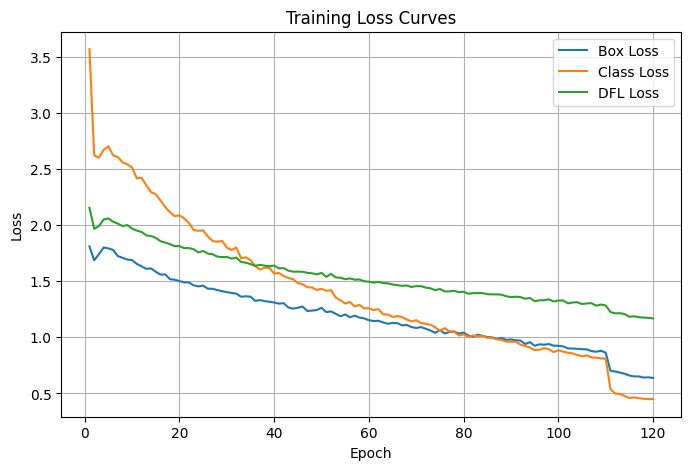

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(results['epoch'], results['train/box_loss'], label='Box Loss')
plt.plot(results['epoch'], results['train/cls_loss'], label='Class Loss')
plt.plot(results['epoch'], results['train/dfl_loss'], label='DFL Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curves")
plt.legend()
plt.grid()

plt.show()

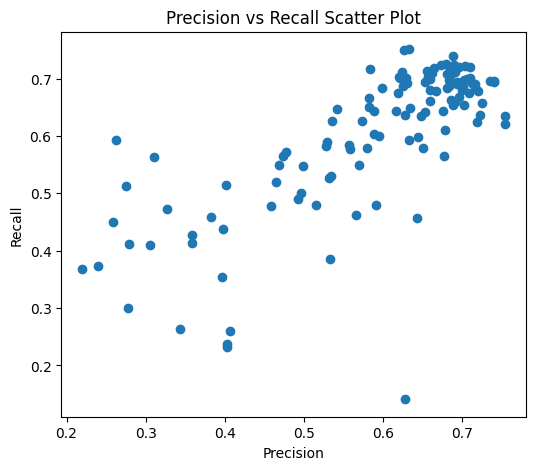

In [ ]:
plt.figure(figsize=(6,5))

plt.scatter(results['metrics/precision(B)'], results['metrics/recall(B)'])

plt.xlabel("Precision")
plt.ylabel("Recall")
plt.title("Precision vs Recall Scatter Plot")

plt.show()

/tmp/ipykernel_5093/4276860090.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(metric_data, labels=['Precision','Recall'])


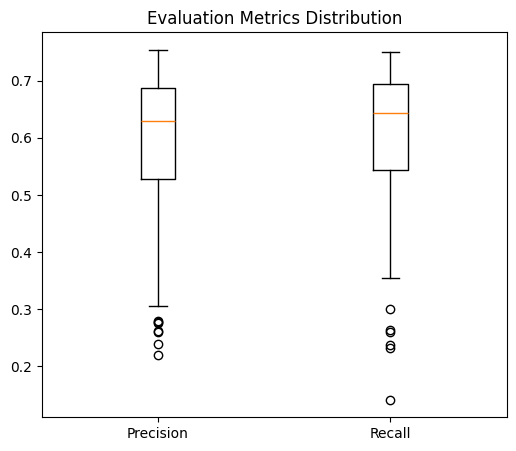

In [ ]:
plt.figure(figsize=(6,5))

metric_data = [
    results['metrics/precision(B)'],
    results['metrics/recall(B)']
]

plt.boxplot(metric_data, labels=['Precision','Recall'])

plt.title("Evaluation Metrics Distribution")

plt.show()